**Final CSCI 347 Project - PCA and Clustering Analysis**

- PCA, k-PCA, k-means, DBSCAN

***PCA -------------------------------------------------------***

(120, 11)


Text(0, 0.5, 'PC2')

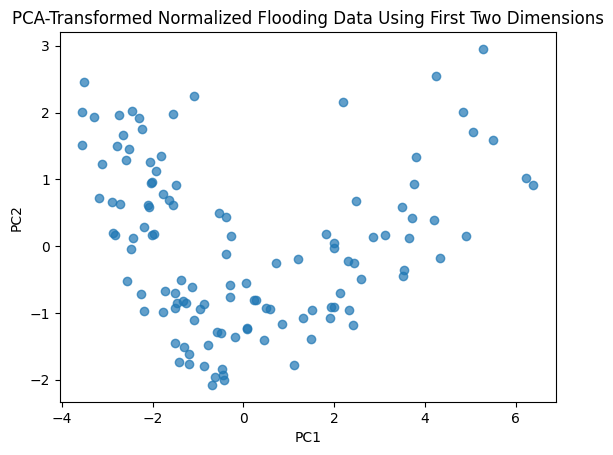

In [2]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Storm: storm_min_distance_km, storm_within_300km
# Meterological: RH2M_max, WS2M_max
# Rain: rain_3day, api_k_0_90, 6hr_intensity_mm_hr_max
# Hydrological: max_percentile, duration_above_90, area_above_90

D = np.loadtxt('master_event_level_filled.csv', 
              skiprows=1, 
              # skips first 5 columns
              usecols=(5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15), 
              delimiter=',',
              dtype=object)
# Normalize data
scaler = StandardScaler()
flooding_scaled = scaler.fit_transform(D)
print(flooding_scaled.shape)

# PCA on flooding_scaled
pca = PCA()
transformed_pca_flooding = pca.fit_transform(flooding_scaled)
transformed_pca_flooding

# Scatter plot of PCA flooding data
D2_pca_scaled = transformed_pca_flooding[:,0:2]
plt.scatter(D2_pca_scaled[:,0], D2_pca_scaled[:,1], alpha = 0.7)
plt.title('PCA-Transformed Normalized Flooding Data Using First Two Dimensions')
plt.xlabel('PC1')
plt.ylabel('PC2')

The first two PCA dimensions show an overall nonlinear trend in the data making a "U" shape. No apparent clustering is shown. Perhaps there could be some linear clustering from -2 to 6 in PC1 and from -4 to 0 in PC1 as well.

***k-PCA ------------------------------------------------------------***

Text(0, 0.5, 'PC2')

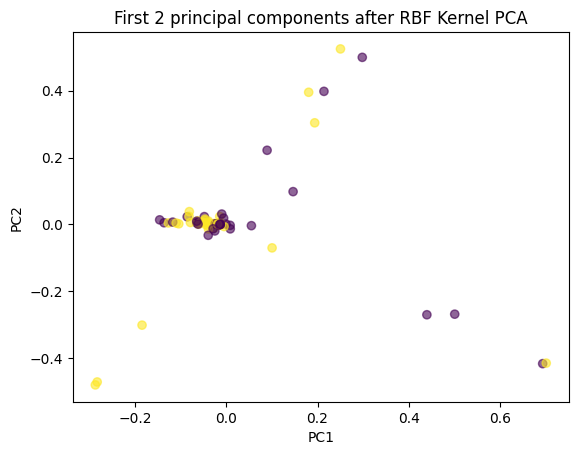

In [3]:
from sklearn.decomposition import KernelPCA

# get binary color labels
y = np.random.randint(0, 2, 120)

# k PCA
gamma_value = 2
kpca_rbf = KernelPCA(n_components=2, kernel="rbf", gamma=gamma_value)
flooding_kpca_rbf = kpca_rbf.fit_transform(transformed_pca_flooding)

# plot first two components 
plt.scatter(flooding_kpca_rbf[:,0], flooding_kpca_rbf[:,1], alpha=0.6, c=y)
plt.title('First 2 principal components after RBF Kernel PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')

k PCA doesn't look like it works well on this dataset.

***k Means -------------------------------------------------------***

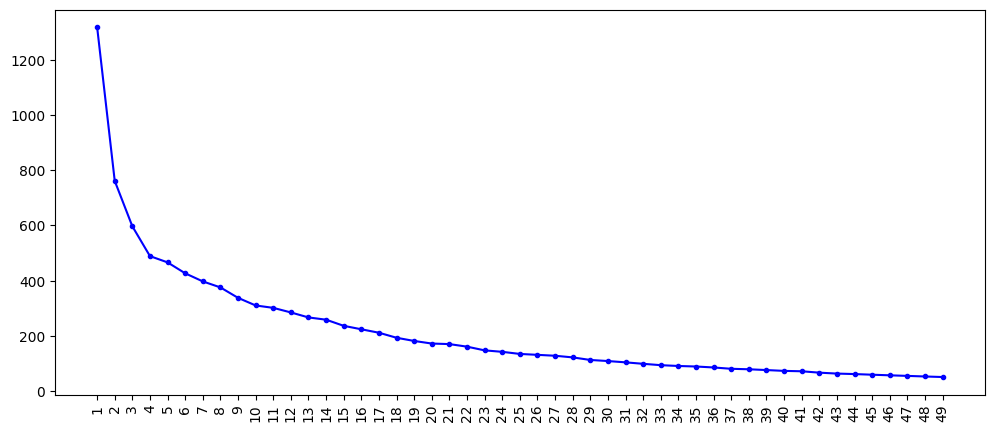

In [4]:
from sklearn.cluster import KMeans

# elbow method
max_clusters = 50
inertias = np.zeros(50)
cluster_range = range(1, max_clusters)
for i in cluster_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, random_state=0)
    kmeans.fit_predict(transformed_pca_flooding)
    inertias[i] = kmeans.inertia_

plt.figure(figsize=(12, 5))
plt.plot(cluster_range, inertias[cluster_range], c='b', marker='.')
plt.xticks(cluster_range, rotation='vertical')
pass

Based off the elbow method, 4 clusters would be the best choice because we stop seeing significant improvement after that.

Inertia value after elbow method:  488.68249386438845


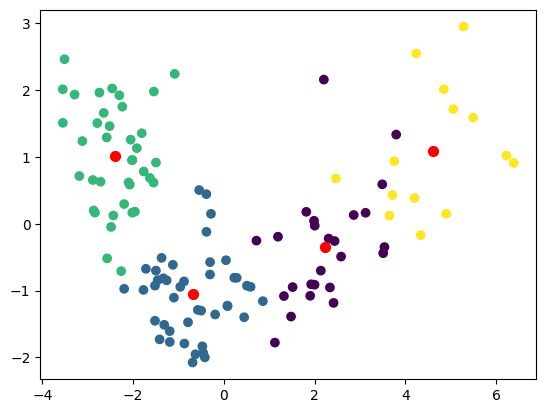

In [5]:
# K means on 4 clusters based on elbow method
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, random_state=0)
pred_cluster_labels_4 = kmeans.fit_predict(transformed_pca_flooding)
plt.scatter(transformed_pca_flooding[:,0], transformed_pca_flooding[:,1], c=pred_cluster_labels_4)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=50, c='red')
print('Inertia value after elbow method: ', kmeans.inertia_)

K Means doesn't appear to be a good representative of this data

***DBSCAN -------------------------------------------------------***

Estimated number of clusters: 3
Estimated number of noise points: 30


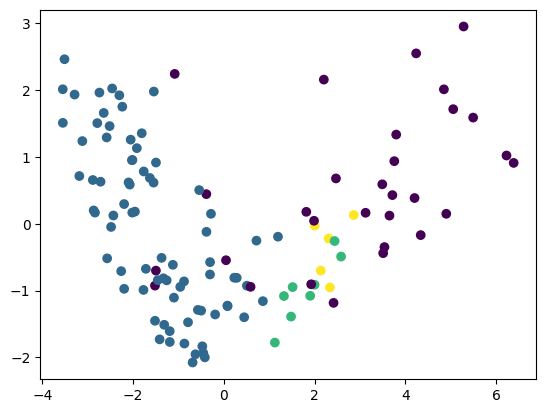

In [11]:
from sklearn.cluster import DBSCAN
from sklearn import metrics

db = DBSCAN(eps=1.7, min_samples=5)
pred_labels = db.fit_predict(transformed_pca_flooding)

n_clusters_ = len(set(pred_labels)) - (1 if -1 in pred_labels else 0)
n_noise_ = list(pred_labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

plt.scatter(transformed_pca_flooding[:,0], transformed_pca_flooding[:,1], c=pred_labels)